In [10]:
# RRCP (02/08/2026): Notebook de Regresion Lineal
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

In [4]:
# Cargar Datos
df_partido = pd.read_csv("../data/partidos_cebollitas_30072026.csv")

# Crear variable objetivo
df_partido['diferencia_goles'] = df_partido['goles_local'] - df_partido['goles_visitante']

# Variable predictoras
X = df_partido[['posesion_local (%)', 'tiros_arco_local']]
y = df_partido['diferencia_goles']

# División estpandar: 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Instancia y Entrenar el modelo
modelo_rl = LinearRegression()
modelo_rl.fit(X_train, y_train)

print("¡Modelo entrenado exitosamente!")

¡Modelo entrenado exitosamente!


In [8]:
# Mostrar coeficientes
print(f"Intercepto (bo): {modelo_rl.intercept_}")
print(f"Coeficientes (beta): {modelo_rl.coef_}")

# Interpretación amigable
for idx, col_name in enumerate(X.columns):
    print(f"Si aumentamos 1 unidad en '{col_name}', la diferencia de goles cambia en primedio {modelo_rl.coef_[idx]:.2f}")

Intercepto (bo): -2.5257192572329763
Coeficientes (beta): [ 0.05596278 -0.05125811]
Si aumentamos 1 unidad en 'posesion_local (%)', la diferencia de goles cambia en primedio 0.06
Si aumentamos 1 unidad en 'tiros_arco_local', la diferencia de goles cambia en primedio -0.05


In [9]:
# Hacer predicciones
y_pred = modelo_rl.predict(X_test)

# Comparar predicciones vs valores reales
df_resultados = X_test.copy()
df_resultados['Diferencia_Goles_Real'] = y_test
df_resultados['Diferencia_Goles_Predicha'] = y_pred.round(2)

df_resultados.head(10)

,posesion_local (%),tiros_arco_local,Diferencia_Goles_Real,Diferencia_Goles_Predicha
83,47,3,3,-0.05
53,60,3,3,0.68
70,50,5,0,0.02
45,57,7,3,0.31
44,45,5,5,-0.26
39,60,7,3,0.47
22,45,11,0,-0.57
80,49,5,1,-0.04
10,48,5,-2,-0.10
0,54,12,2,-0.12


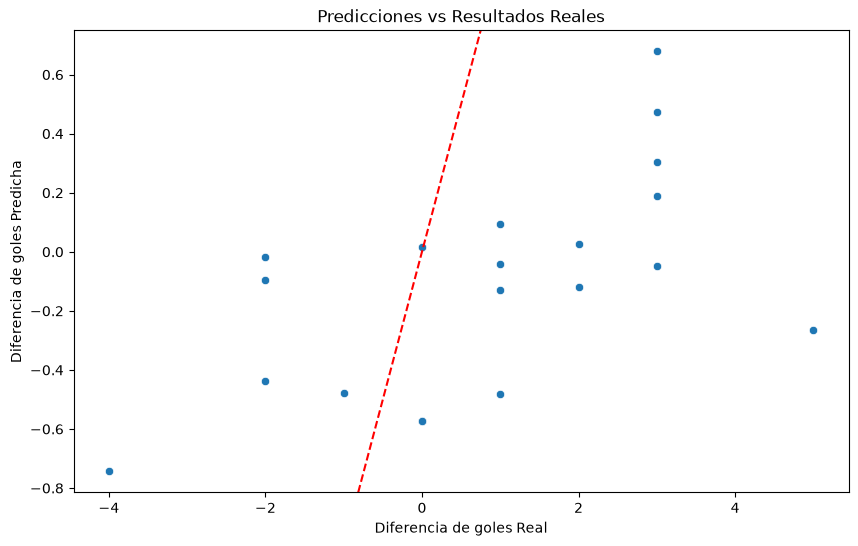

In [11]:
# Crear gráfico de dispersión
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Diferencia de goles Real')
plt.ylabel('Diferencia de goles Predicha')
plt.title('Predicciones vs Resultados Reales')
plt.axline((0,0), slope = 1, color = 'red', linestyle = '--') # Linea ideal
plt.show()

In [ ]:
# Widget de entrada
posesion_input = widgets.FloatSlider(min=30, max=70, step=1, description='Posesion (%)')
tiros_input = widgets.IntSlider(min=1, max=15, step=1, description= 'Tiros al Arco')

# Funcion Predicción
def predecir_goles(posesion, tiros):
    # Crear DataFrame con nombres de columnas esperados por el modelo
    entrada = pd.DataFrame([[posesion, tiros]], # Datos ingresados como parámetros.
                           columns = ['posesion_local (%)', 'tiros_arco_local']) #Columnas con las que fue entrenado el modelo.
    # Envía los datos al modelo entrenado y extrae la predicción como un número.
    # realiza tres acciones consecutivas:
    #   1. Envía el DataFrame entrada al modelo entrenado (modelo_rl).
    #   2.Obtiene la predicción (que predict() devuelve como un arreglo de NumPy).
    #   3. Extrae el primer y único valor de ese arreglo mediante [0].
    pred = modelo_rl.predict(entrada)[0] #Entender esta linea.
    print(f"Diferencia de goles predicha: {pred:.2f}") #Entender esta linea.


# Mostrar widget interactivo
widgets.interactive(predecir_goles, posesion = posesion_input, tiros=tiros_input)




interactive(children=(FloatSlider(value=30.0, description='Posesion (%)', max=70.0, min=30.0, step=1.0), IntSl…